# Model Deep Dive — Controlled Comparison Study

Systematic evaluation of how **volatility dynamics** and **tail shape** independently affect risk estimates.

**3 tiers tested across 3 assets:**
- **Baseline**: Constant vol + Normal shocks
- **GARCH + Student-t**: Time-varying vol + fat-tailed shocks
- **MS-GARCH + EVT**: Regime-switching GARCH + GPD tails per regime

**Structure:**
1. Data & Setup (3 assets)
2. Comparison 1 — Pure tail effect (fix vol, vary innovations)
3. Comparison 2 — Pure vol effect (fix innovations, vary vol model)
4. Comparison 3 — The 3 tiers head-to-head
5. MS-GARCH model details
6. Tail risk audit (EVT & XGBoost)
7. Backtest validation
8. Horizon dependence — vol vs tail effect across timeframes
9. Conclusions

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import kurtosis

from src.data.fetch import fetch_asset_data
from src.data.process import clean_market_data, add_returns
from src.analytics.monte_carlo import (
    simulate_paths, simulation_summary, compute_var, compute_cvar,
    fit_garch, fit_t_distribution,
)
from src.analytics.ms_garch import fit_ms_garch
from src.analytics.evt import evt_summary, normal_var, normal_cvar
from src.analytics.xgb_var import fit_quantile_model

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Data & Setup

Three assets with different tail/volatility profiles:
- **BTC-USD** — crypto, extreme tails, high vol
- **SPY** — equity index, moderate tails, lower vol
- **NVDA** — volatile equity, somewhere in between

In [2]:
TICKERS = ["BTC-USD", "SPY", "NVDA"]
N_DAYS = 252
N_SIMS = 10_000
SEED = 42

assets = {}
for ticker in TICKERS:
    raw = fetch_asset_data(ticker)
    df = clean_market_data(raw)
    df = add_returns(df)
    assets[ticker] = {
        "returns": df["returns"],
        "close": df["close"],
        "initial_price": df["close"].iloc[-1],
        "n_days": len(df),
    }
    print(f"{ticker}: {len(df)} trading days, "
          f"ann. vol = {df['returns'].std() * np.sqrt(252):.2%}, "
          f"kurtosis = {kurtosis(df['returns'].dropna()):.2f}")

BTC-USD: 1823 trading days, ann. vol = 46.71%, kurtosis = 3.65
SPY: 1254 trading days, ann. vol = 17.09%, kurtosis = 9.18
NVDA: 1254 trading days, ann. vol = 51.68%, kurtosis = 4.70


## 2. Comparison 1 — Pure Tail Effect

**Fix volatility model = GARCH**, vary only the innovation distribution:
- GARCH + Normal shocks
- GARCH + Student-t shocks (default)

This isolates the impact of fat-tailed innovations while keeping volatility dynamics identical.

In [3]:
tail_results = {}

for ticker, data in assets.items():
    close, returns = data["close"], data["returns"]
    ip = data["initial_price"]
    garch_params = fit_garch(returns)
    t_info = fit_t_distribution(returns)

    configs = {
        "GARCH+Normal": {"volatility_model": "garch", "garch_params": garch_params, "innovation": "normal"},
        "GARCH+Student-t": {"volatility_model": "garch", "garch_params": garch_params},  # default innovation="t"
    }

    tail_results[ticker] = {"t_df": t_info["df"]}
    for name, kwargs in configs.items():
        paths = simulate_paths(close, returns, n_days=N_DAYS, n_simulations=N_SIMS, seed=SEED, **kwargs)
        fp = paths.iloc[-1]
        sim_returns = (fp - ip) / ip
        s95 = simulation_summary(fp, ip, 0.95)
        s99 = simulation_summary(fp, ip, 0.99)
        tail_results[ticker][name] = {
            "var_95": s95["var"], "cvar_95": s95["cvar"],
            "var_99": s99["var"], "cvar_99": s99["cvar"],
            "prob_gain": s95["prob_gain"],
            "kurtosis": float(kurtosis(fp)),
            "fp": fp,
        }

    print(f"{ticker} — Student-t df={t_info['df']:.1f} ({t_info['tail_description']})")

print("\nDone.")

BTC-USD — Student-t df=2.7 (Very heavy tails)
SPY — Student-t df=3.8 (Very heavy tails)
NVDA — Student-t df=5.1 (Moderately heavy tails)

Done.


In [4]:
# Summary table: tail effect
rows = []
for ticker, results in tail_results.items():
    for name in ["GARCH+Normal", "GARCH+Student-t"]:
        r = results[name]
        rows.append({
            "Asset": ticker, "Innovation": name.split("+")[1],
            "VaR 95%": f"{r['var_95']:.2%}", "CVaR 95%": f"{r['cvar_95']:.2%}",
            "VaR 99%": f"{r['var_99']:.2%}", "CVaR 99%": f"{r['cvar_99']:.2%}",
            "Kurtosis": f"{r['kurtosis']:.2f}",
        })

df_tail = pd.DataFrame(rows)
print("Pure Tail Effect (GARCH vol held constant):")
df_tail

Pure Tail Effect (GARCH vol held constant):


,Asset,Innovation,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%,Kurtosis
0,BTC-USD,Normal,-53.23%,-61.39%,-67.20%,-72.34%,5.72
1,BTC-USD,Student-t,-46.64%,-60.33%,-69.39%,-82.06%,91.28
2,SPY,Normal,-15.67%,-22.20%,-26.73%,-31.97%,1.00
3,SPY,Student-t,-13.72%,-22.80%,-27.69%,-38.56%,10.17
4,NVDA,Normal,-30.55%,-43.73%,-53.04%,-60.30%,6.66
5,NVDA,Student-t,-32.06%,-46.81%,-55.87%,-65.78%,37.70


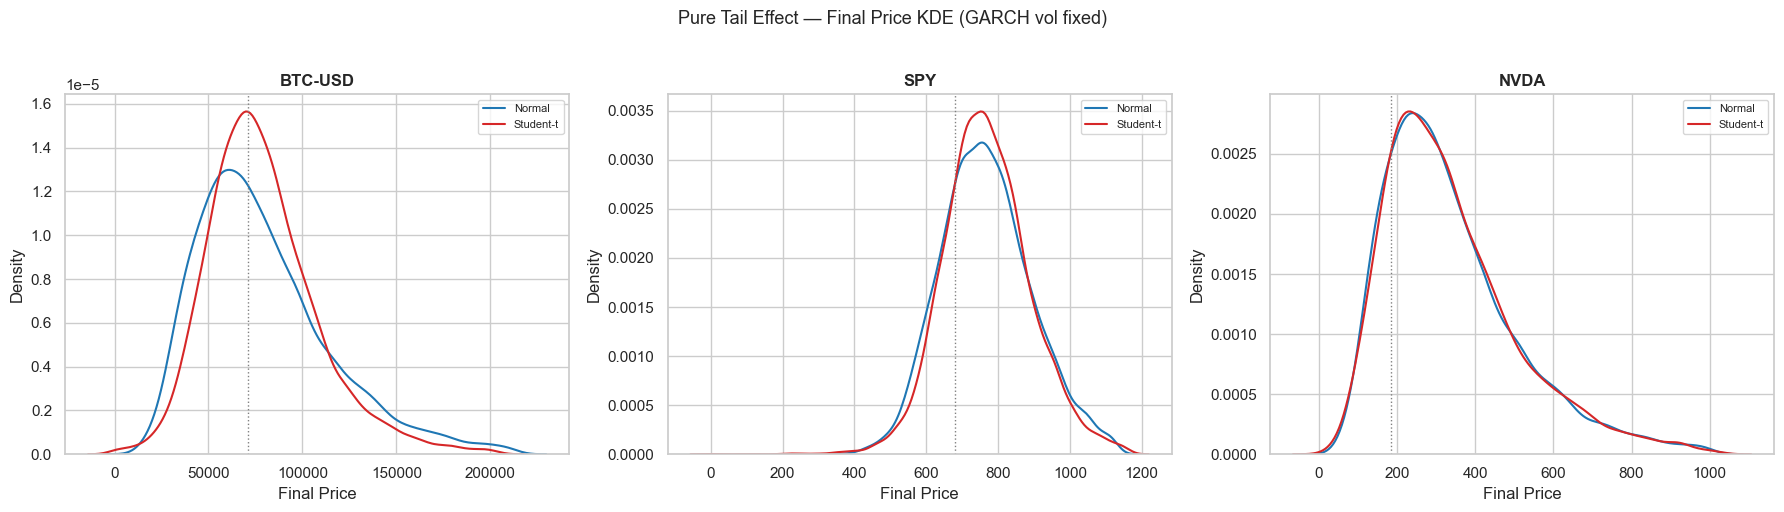

In [5]:
# KDE overlay: Normal vs Student-t final prices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {"GARCH+Normal": "#1f77b4", "GARCH+Student-t": "#d62728"}

for ax, (ticker, results) in zip(axes, tail_results.items()):
    ip = assets[ticker]["initial_price"]
    for name, c in colors.items():
        # Trim at p99 for readability
        fp = results[name]["fp"]
        cutoff = fp.quantile(0.99)
        sns.kdeplot(fp[fp <= cutoff], ax=ax, label=name.split("+")[1], color=c, linewidth=1.5)
    ax.axvline(ip, color="gray", linewidth=1, linestyle=":")
    ax.set_title(f"{ticker}", fontweight="bold")
    ax.set_xlabel("Final Price")
    ax.legend(fontsize=8)

fig.suptitle("Pure Tail Effect — Final Price KDE (GARCH vol fixed)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

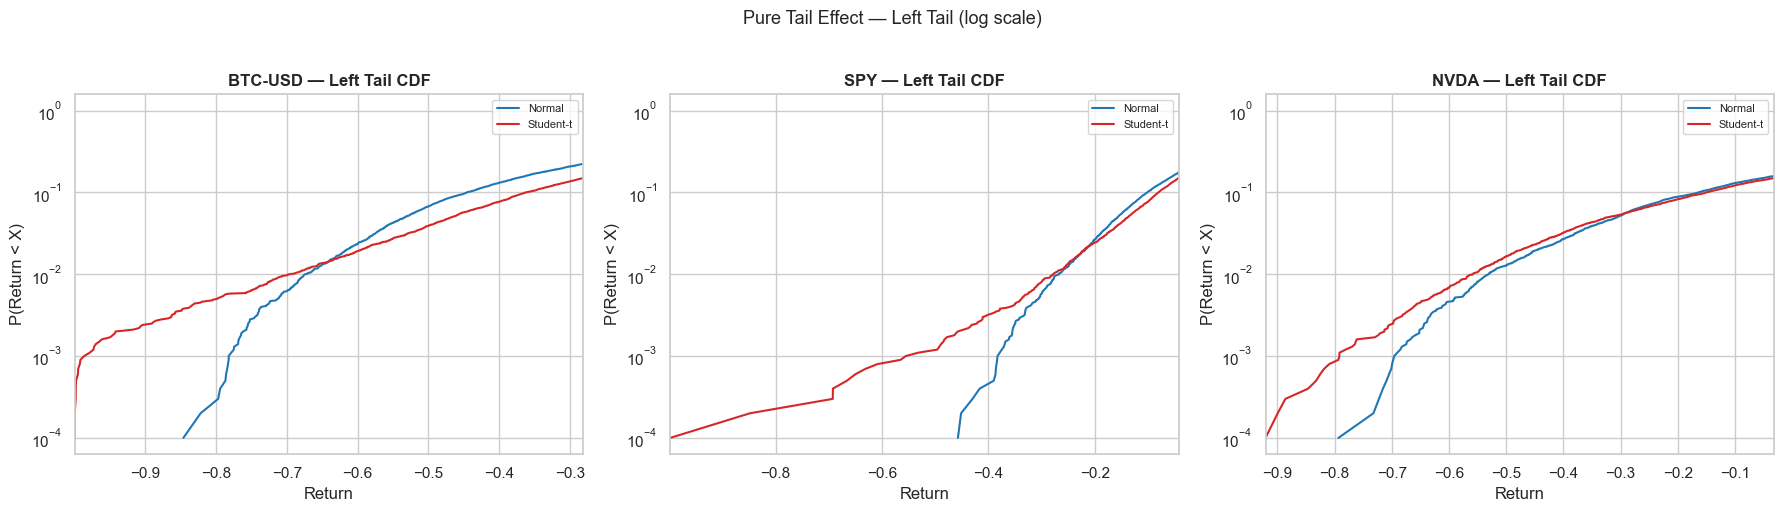

In [6]:
# Left-tail survival function (log scale) — where tail differences matter most
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (ticker, results) in zip(axes, tail_results.items()):
    ip = assets[ticker]["initial_price"]
    for name, c in colors.items():
        fp = results[name]["fp"]
        ret = ((fp - ip) / ip).sort_values()
        cdf = np.arange(1, len(ret) + 1) / len(ret)
        ax.plot(ret.values, cdf, label=name.split("+")[1], color=c, linewidth=1.5)
    ax.set_xlim(ret.quantile(0.0), ret.quantile(0.15))
    ax.set_yscale("log")
    ax.set_title(f"{ticker} — Left Tail CDF", fontweight="bold")
    ax.set_xlabel("Return")
    ax.set_ylabel("P(Return < X)")
    ax.legend(fontsize=8)

fig.suptitle("Pure Tail Effect — Left Tail (log scale)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Comparison 2 — Pure Vol Effect

**Fix innovation = Normal**, vary only the volatility model:
- Constant vol + Normal
- GARCH + Normal (forced via `innovation="normal"`)

This isolates the impact of time-varying volatility dynamics while keeping the tail shape identical.

In [7]:
vol_results = {}

for ticker, data in assets.items():
    close, returns = data["close"], data["returns"]
    ip = data["initial_price"]
    garch_params = fit_garch(returns)

    configs = {
        "Constant+Normal": {"volatility_model": "constant"},
        "GARCH+Normal": {"volatility_model": "garch", "garch_params": garch_params, "innovation": "normal"},
    }

    vol_results[ticker] = {}
    for name, kwargs in configs.items():
        paths = simulate_paths(close, returns, n_days=N_DAYS, n_simulations=N_SIMS, seed=SEED, **kwargs)
        fp = paths.iloc[-1]
        s95 = simulation_summary(fp, ip, 0.95)
        s99 = simulation_summary(fp, ip, 0.99)
        vol_results[ticker][name] = {
            "var_95": s95["var"], "cvar_95": s95["cvar"],
            "var_99": s99["var"], "cvar_99": s99["cvar"],
            "prob_gain": s95["prob_gain"],
            "kurtosis": float(kurtosis(fp)),
            "fp": fp,
        }

print("Done.")

Done.


In [8]:
# Summary table: vol effect
rows = []
for ticker, results in vol_results.items():
    for name in ["Constant+Normal", "GARCH+Normal"]:
        r = results[name]
        rows.append({
            "Asset": ticker, "Vol Model": name.split("+")[0],
            "VaR 95%": f"{r['var_95']:.2%}", "CVaR 95%": f"{r['cvar_95']:.2%}",
            "VaR 99%": f"{r['var_99']:.2%}", "CVaR 99%": f"{r['cvar_99']:.2%}",
            "Kurtosis": f"{r['kurtosis']:.2f}",
        })

df_vol = pd.DataFrame(rows)
print("Pure Vol Effect (Normal shocks held constant):")
df_vol

Pure Vol Effect (Normal shocks held constant):


,Asset,Vol Model,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%,Kurtosis
0,BTC-USD,Constant,-52.52%,-60.45%,-65.85%,-70.32%,3.91
1,BTC-USD,GARCH,-53.23%,-61.39%,-67.20%,-72.34%,5.72
2,SPY,Constant,-15.33%,-21.05%,-24.95%,-28.83%,0.34
3,SPY,GARCH,-15.67%,-22.20%,-26.73%,-31.97%,1.00
4,NVDA,Constant,-29.49%,-42.31%,-51.03%,-58.05%,5.13
5,NVDA,GARCH,-30.55%,-43.73%,-53.04%,-60.30%,6.66


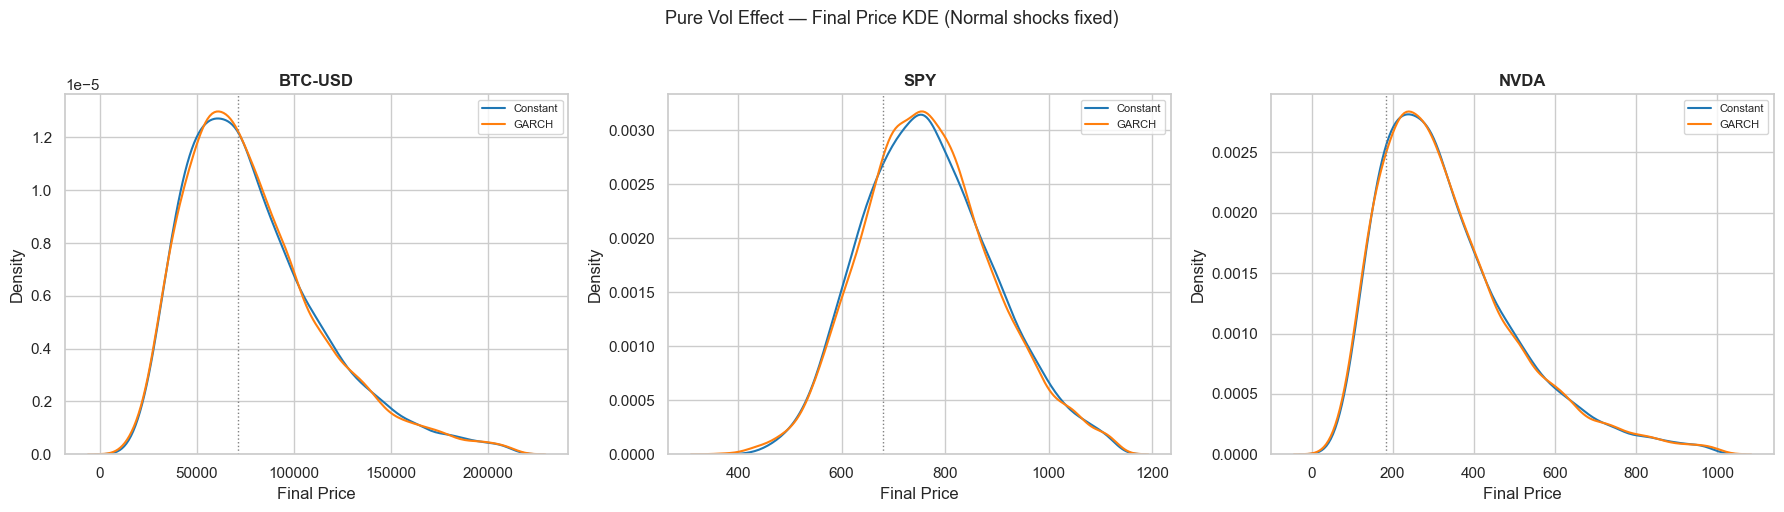

In [9]:
# KDE overlay: Constant vs GARCH (both Normal shocks)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_vol = {"Constant+Normal": "#1f77b4", "GARCH+Normal": "#ff7f0e"}

for ax, (ticker, results) in zip(axes, vol_results.items()):
    ip = assets[ticker]["initial_price"]
    for name, c in colors_vol.items():
        fp = results[name]["fp"]
        cutoff = fp.quantile(0.99)
        sns.kdeplot(fp[fp <= cutoff], ax=ax, label=name.split("+")[0], color=c, linewidth=1.5)
    ax.axvline(ip, color="gray", linewidth=1, linestyle=":")
    ax.set_title(f"{ticker}", fontweight="bold")
    ax.set_xlabel("Final Price")
    ax.legend(fontsize=8)

fig.suptitle("Pure Vol Effect — Final Price KDE (Normal shocks fixed)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Volatility influence gets dissolved over time. Better approach would be 21 days

Done.
Pure Vol Effect (Normal shocks held constant):


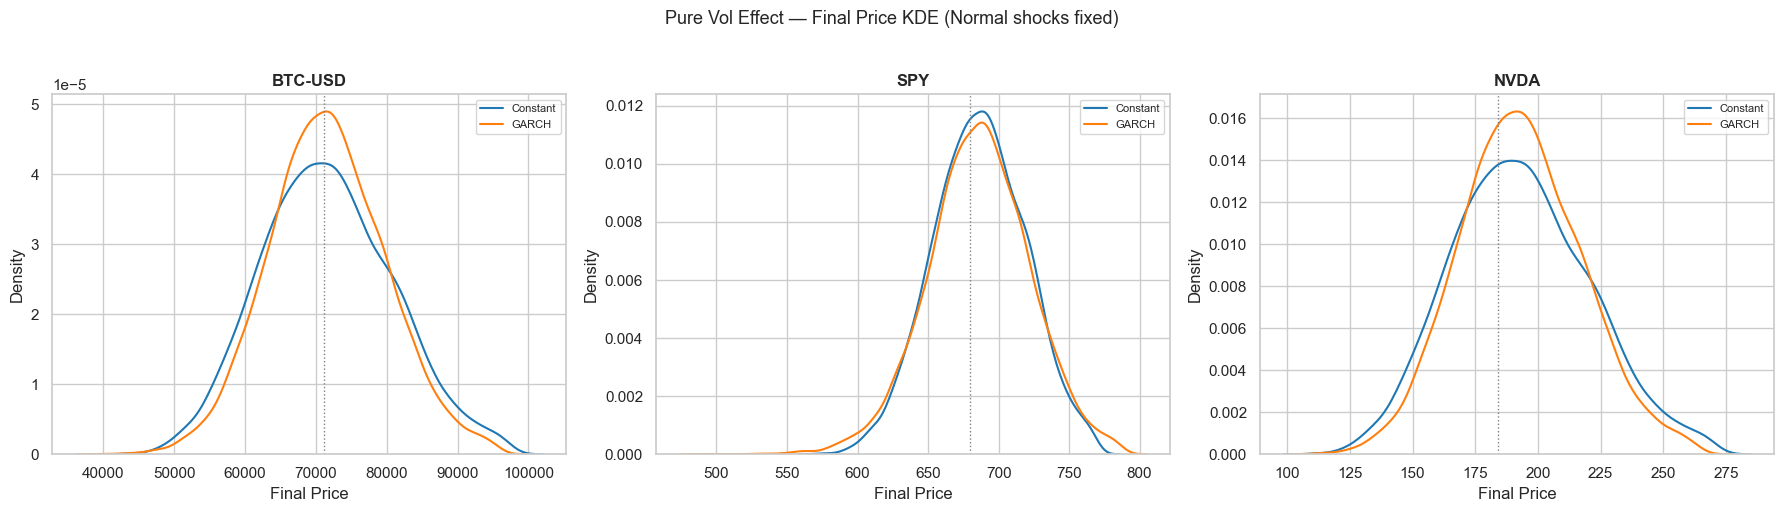

In [10]:
vol_results = {}

for ticker, data in assets.items():
    close, returns = data["close"], data["returns"]
    ip = data["initial_price"]
    garch_params = fit_garch(returns)

    configs = {
        "Constant+Normal": {"volatility_model": "constant"},
        "GARCH+Normal": {"volatility_model": "garch", "garch_params": garch_params, "innovation": "normal"},
    }

    vol_results[ticker] = {}
    for name, kwargs in configs.items():
        paths = simulate_paths(close, returns, n_days=21, n_simulations=N_SIMS, seed=SEED, **kwargs)
        fp = paths.iloc[-1]
        s95 = simulation_summary(fp, ip, 0.95)
        s99 = simulation_summary(fp, ip, 0.99)
        vol_results[ticker][name] = {
            "var_95": s95["var"], "cvar_95": s95["cvar"],
            "var_99": s99["var"], "cvar_99": s99["cvar"],
            "prob_gain": s95["prob_gain"],
            "kurtosis": float(kurtosis(fp)),
            "fp": fp,
        }

print("Done.")

# Summary table: vol effect
rows = []
for ticker, results in vol_results.items():
    for name in ["Constant+Normal", "GARCH+Normal"]:
        r = results[name]
        rows.append({
            "Asset": ticker, "Vol Model": name.split("+")[0],
            "VaR 95%": f"{r['var_95']:.2%}", "CVaR 95%": f"{r['cvar_95']:.2%}",
            "VaR 99%": f"{r['var_99']:.2%}", "CVaR 99%": f"{r['cvar_99']:.2%}",
            "Kurtosis": f"{r['kurtosis']:.2f}",
        })

df_vol = pd.DataFrame(rows)
print("Pure Vol Effect (Normal shocks held constant):")
df_vol

# KDE overlay: Constant vs GARCH (both Normal shocks)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_vol = {"Constant+Normal": "#1f77b4", "GARCH+Normal": "#ff7f0e"}

for ax, (ticker, results) in zip(axes, vol_results.items()):
    ip = assets[ticker]["initial_price"]
    for name, c in colors_vol.items():
        fp = results[name]["fp"]
        cutoff = fp.quantile(0.99)
        sns.kdeplot(fp[fp <= cutoff], ax=ax, label=name.split("+")[0], color=c, linewidth=1.5)
    ax.axvline(ip, color="gray", linewidth=1, linestyle=":")
    ax.set_title(f"{ticker}", fontweight="bold")
    ax.set_xlabel("Final Price")
    ax.legend(fontsize=8)

fig.suptitle("Pure Vol Effect — Final Price KDE (Normal shocks fixed)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Comparison 3 — The 3 Tiers Head-to-Head

The three models that will go into the app, each adding one layer of complexity:

| Tier | Volatility | Shocks | What it captures |
|------|-----------|--------|------------------|
| **Baseline** | Constant sigma | Normal | Symmetric risk, no clustering |
| **GARCH + Student-t** | Time-varying sigma | Student-t | Vol clustering + fat tails |
| **MS-GARCH + EVT** | Regime-switching GARCH | GPD tails | Regime changes + extreme tails |

In [11]:
tier_results = {}

for ticker, data in assets.items():
    close, returns = data["close"], data["returns"]
    ip = data["initial_price"]

    garch_params = fit_garch(returns)
    ms_params = fit_ms_garch(returns, n_regimes=2, seed=SEED)

    tier_configs = {
        "Baseline": {"volatility_model": "constant"},
        "GARCH+t": {"volatility_model": "garch", "garch_params": garch_params},
        "MS-GARCH+EVT": {"volatility_model": "ms_garch", "ms_garch_params": ms_params},
    }

    tier_results[ticker] = {"ms_params": ms_params}
    for name, kwargs in tier_configs.items():
        paths = simulate_paths(close, returns, n_days=N_DAYS, n_simulations=N_SIMS, seed=SEED, **kwargs)
        fp = paths.iloc[-1]
        sim_returns = (fp - ip) / ip
        s95 = simulation_summary(fp, ip, 0.95)
        s99 = simulation_summary(fp, ip, 0.99)
        tier_results[ticker][name] = {
            "var_95": s95["var"], "cvar_95": s95["cvar"],
            "var_99": s99["var"], "cvar_99": s99["cvar"],
            "prob_gain": s95["prob_gain"],
            "kurtosis": float(kurtosis(fp)),
            "p_loss_30": float((sim_returns < -0.30).mean()),
            "p_loss_50": float((sim_returns < -0.50).mean()),
            "paths": paths,
            "fp": fp,
        }

    print(f"{ticker} — 3 tiers simulated")

print("\nDone.")

BTC-USD — 3 tiers simulated
SPY — 3 tiers simulated
NVDA — 3 tiers simulated

Done.


In [12]:
# Summary table: 3 tiers across 3 assets
rows = []
tier_names = ["Baseline", "GARCH+t", "MS-GARCH+EVT"]

for ticker in TICKERS:
    for name in tier_names:
        r = tier_results[ticker][name]
        rows.append({
            "Asset": ticker, "Tier": name,
            "VaR 95%": f"{r['var_95']:.2%}", "CVaR 95%": f"{r['cvar_95']:.2%}",
            "VaR 99%": f"{r['var_99']:.2%}", "CVaR 99%": f"{r['cvar_99']:.2%}",
            "P(Gain)": f"{r['prob_gain']:.1%}",
            "P(Loss>30%)": f"{r['p_loss_30']:.1%}",
            "P(Loss>50%)": f"{r['p_loss_50']:.1%}",
            "Kurtosis": f"{r['kurtosis']:.2f}",
        })

df_tiers = pd.DataFrame(rows)
print("3 Tiers x 3 Assets — Full Comparison:")
df_tiers

3 Tiers x 3 Assets — Full Comparison:


,Asset,Tier,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%,P(Gain),P(Loss>30%),P(Loss>50%),Kurtosis
0,BTC-USD,Baseline,-52.52%,-60.45%,-65.85%,-70.32%,52.0%,21.2%,6.4%,3.91
1,BTC-USD,GARCH+t,-46.64%,-60.33%,-69.39%,-82.06%,56.4%,13.7%,3.9%,91.28
2,BTC-USD,MS-GARCH+EVT,-70.91%,-77.39%,-81.71%,-85.33%,43.9%,35.9%,19.4%,9.96
3,SPY,Baseline,-15.33%,-21.05%,-24.95%,-28.83%,74.6%,0.3%,0.0%,0.34
4,SPY,GARCH+t,-13.72%,-22.80%,-27.69%,-38.56%,78.2%,0.8%,0.1%,10.17
5,SPY,MS-GARCH+EVT,-23.59%,-35.34%,-42.28%,-54.34%,76.4%,2.8%,0.5%,0.69
6,NVDA,Baseline,-29.49%,-42.31%,-51.03%,-58.05%,83.0%,4.9%,1.1%,5.13
7,NVDA,GARCH+t,-32.06%,-46.81%,-55.87%,-65.78%,83.6%,5.3%,1.7%,37.70
8,NVDA,MS-GARCH+EVT,-36.70%,-50.50%,-59.29%,-67.67%,82.2%,6.9%,2.2%,7.75


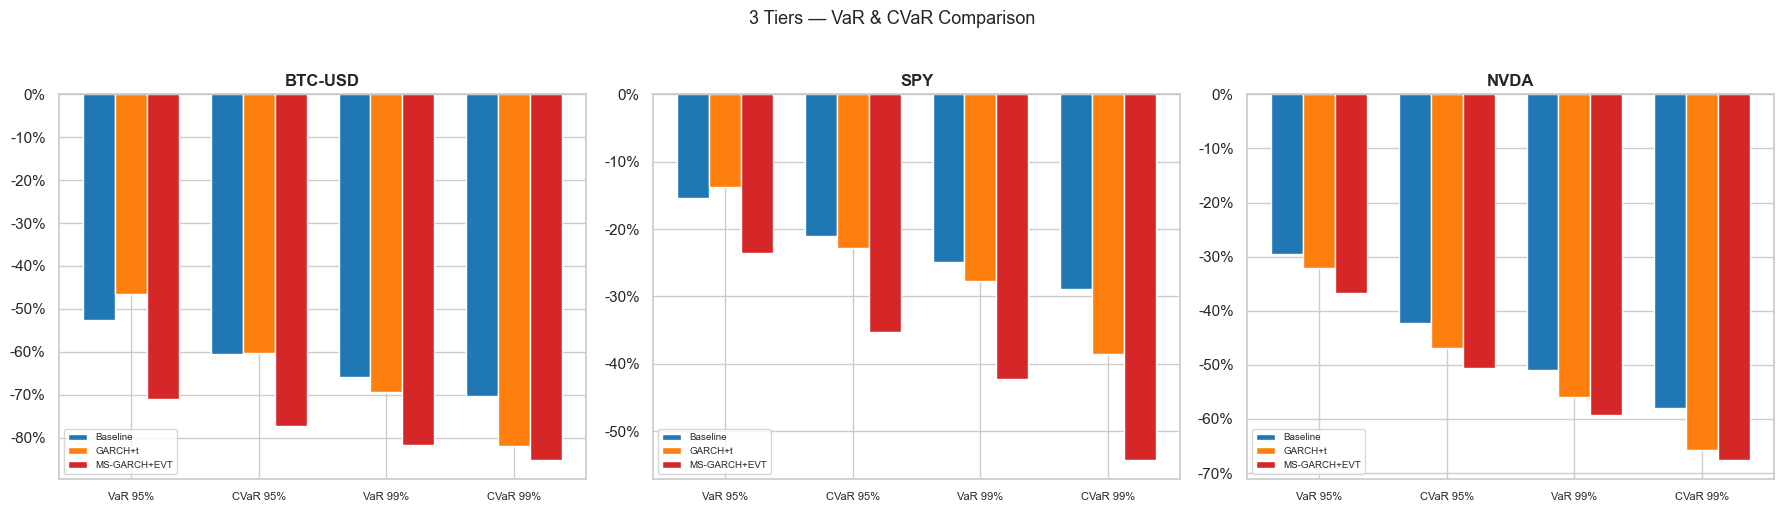

In [13]:
# VaR comparison bar chart per asset
tier_colors = {"Baseline": "#1f77b4", "GARCH+t": "#ff7f0e", "MS-GARCH+EVT": "#d62728"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["var_95", "cvar_95", "var_99", "cvar_99"]
metric_labels = ["VaR 95%", "CVaR 95%", "VaR 99%", "CVaR 99%"]

for ax, ticker in zip(axes, TICKERS):
    x = np.arange(len(metrics))
    width = 0.25
    for i, (name, c) in enumerate(tier_colors.items()):
        vals = [tier_results[ticker][name][m] for m in metrics]
        ax.bar(x + i * width, vals, width, label=name, color=c)
    ax.set_xticks(x + width)
    ax.set_xticklabels(metric_labels, fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(f"{ticker}", fontweight="bold")
    ax.legend(fontsize=7)
    ax.axhline(0, color="gray", linewidth=0.5)

fig.suptitle("3 Tiers — VaR & CVaR Comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

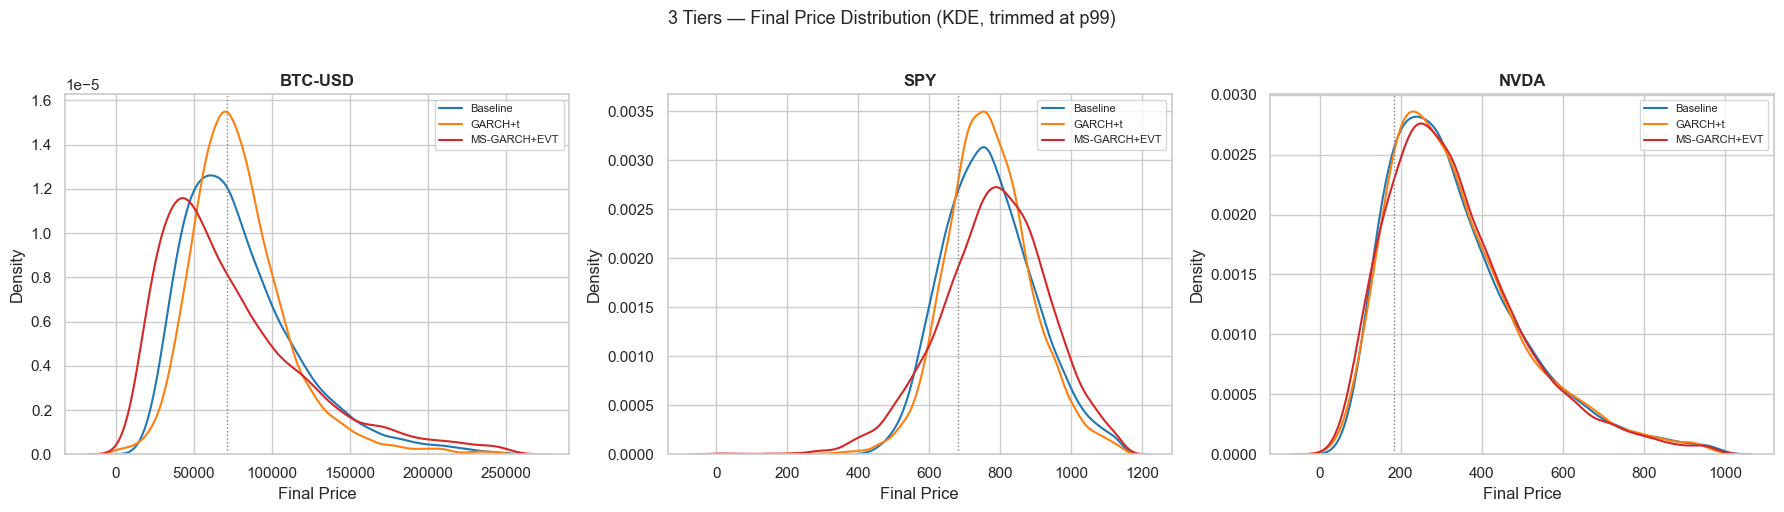

In [14]:
# KDE overlay per asset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ticker in zip(axes, TICKERS):
    ip = assets[ticker]["initial_price"]
    all_fps = [tier_results[ticker][n]["fp"] for n in tier_names]
    cutoff = pd.concat(all_fps).quantile(0.99)
    for name, c in tier_colors.items():
        fp = tier_results[ticker][name]["fp"]
        sns.kdeplot(fp[fp <= cutoff], ax=ax, label=name, color=c, linewidth=1.5)
    ax.axvline(ip, color="gray", linewidth=1, linestyle=":")
    ax.set_title(f"{ticker}", fontweight="bold")
    ax.set_xlabel("Final Price")
    ax.legend(fontsize=8)

fig.suptitle("3 Tiers — Final Price Distribution (KDE, trimmed at p99)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

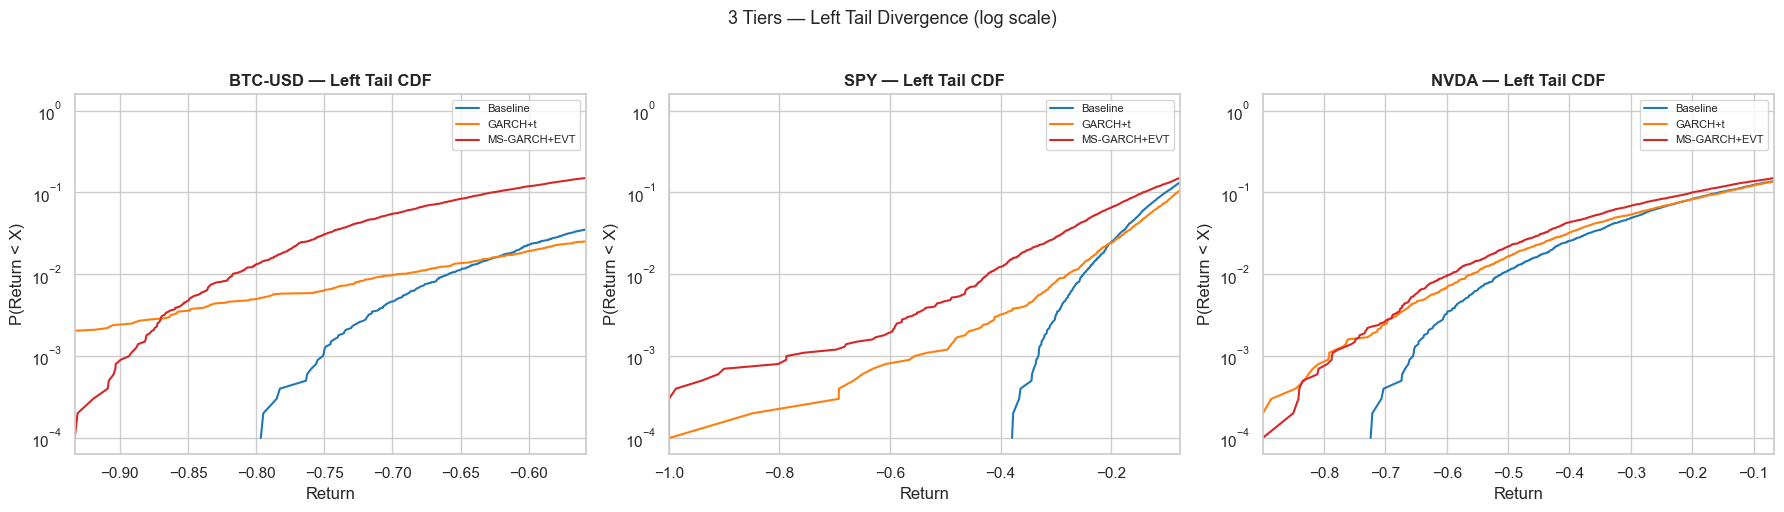

In [15]:
# Left-tail survival: where the 3 tiers diverge
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ticker in zip(axes, TICKERS):
    ip = assets[ticker]["initial_price"]
    for name, c in tier_colors.items():
        fp = tier_results[ticker][name]["fp"]
        ret = ((fp - ip) / ip).sort_values()
        cdf = np.arange(1, len(ret) + 1) / len(ret)
        ax.plot(ret.values, cdf, label=name, color=c, linewidth=1.5)
    ax.set_xlim(ret.quantile(0.0), ret.quantile(0.15))
    ax.set_yscale("log")
    ax.set_title(f"{ticker} — Left Tail CDF", fontweight="bold")
    ax.set_xlabel("Return")
    ax.set_ylabel("P(Return < X)")
    ax.legend(fontsize=8)

fig.suptitle("3 Tiers — Left Tail Divergence (log scale)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

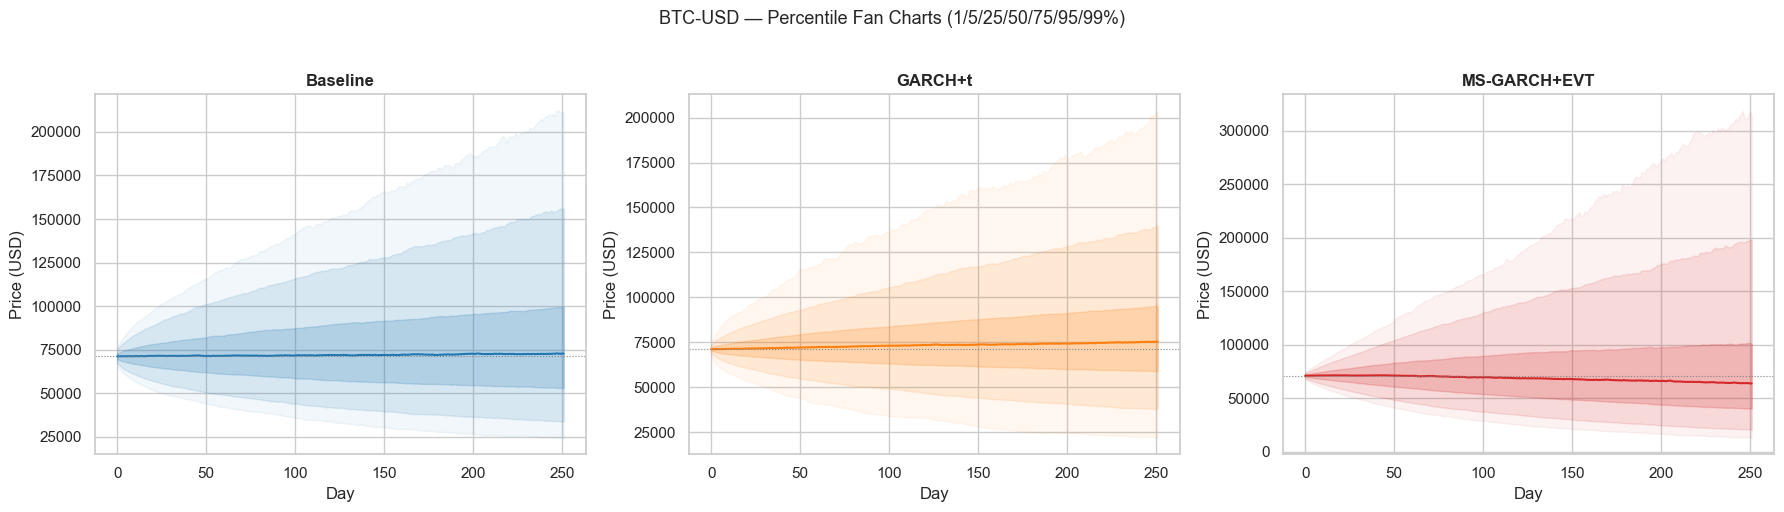

In [16]:
# Percentile fan chart for one asset (BTC — most interesting tails)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]

for ax, (name, c) in zip(axes, tier_colors.items()):
    paths = tier_results["BTC-USD"][name]["paths"]
    pcts = {q: paths.quantile(q, axis=1) for q in quantiles}
    x = paths.index
    ax.fill_between(x, pcts[0.01], pcts[0.99], color=c, alpha=0.06)
    ax.fill_between(x, pcts[0.05], pcts[0.95], color=c, alpha=0.12)
    ax.fill_between(x, pcts[0.25], pcts[0.75], color=c, alpha=0.20)
    ax.plot(x, pcts[0.50], color=c, linewidth=1.5)
    ax.axhline(assets["BTC-USD"]["initial_price"], color="gray", linewidth=0.8, linestyle=":")
    ax.set_title(f"{name}", fontweight="bold")
    ax.set_xlabel("Day")
    ax.set_ylabel("Price (USD)")

fig.suptitle("BTC-USD — Percentile Fan Charts (1/5/25/50/75/95/99%)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4b. Seed Robustness — Are These Estimates Stable?

Single-seed point estimates can be misleading, especially for heavy-tailed distributions (BTC GARCH+t kurtosis=81.77). Run each tier across 10 seeds and check how much VaR/CVaR varies.

In [18]:
from src.analytics.seed_robustness import run_multi_seed, robustness_summary

SEEDS = list(range(0, 100, 10))  # 10 seeds

seed_results = {}
for ticker, data in assets.items():
    close, returns = data["close"], data["returns"]
    garch_params = fit_garch(returns)
    ms_params = tier_results[ticker]["ms_params"]

    tier_configs = {
        "Baseline": {"volatility_model": "constant"},
        "GARCH+t": {"volatility_model": "garch", "garch_params": garch_params},
        "MS-GARCH+EVT": {"volatility_model": "ms_garch", "ms_garch_params": ms_params},
    }

    seed_results[ticker] = {}
    for name, kwargs in tier_configs.items():
        df = run_multi_seed(
            close, returns, n_days=N_DAYS, n_simulations=N_SIMS,
            seeds=SEEDS, **kwargs,
        )
        seed_results[ticker][name] = df
    print(f"{ticker} — seed robustness done")

print("Done.")

BTC-USD — seed robustness done
SPY — seed robustness done
NVDA — seed robustness done
Done.


In [19]:
# Summary table: stability per tier per asset
rows = []
for ticker in TICKERS:
    for name in ["Baseline", "GARCH+t", "MS-GARCH+EVT"]:
        s = robustness_summary(seed_results[ticker][name])
        rows.append({
            "Asset": ticker, "Tier": name,
            "VaR 95% (mean)": f"{s.loc['var_95%', 'mean']:.2%}",
            "VaR 95% (std)": f"{s.loc['var_95%', 'std']:.2%}",
            "VaR 95% (CV)": f"{s.loc['var_95%', 'cv']:.1%}",
            "CVaR 99% (mean)": f"{s.loc['cvar_99%', 'mean']:.2%}",
            "CVaR 99% (std)": f"{s.loc['cvar_99%', 'std']:.2%}",
            "CVaR 99% (CV)": f"{s.loc['cvar_99%', 'cv']:.1%}",
        })

df_stability = pd.DataFrame(rows)
print("Seed Robustness — Coefficient of Variation (CV) across 10 seeds:")
print("CV < 5% = stable, 5-15% = moderate, >15% = unstable")
df_stability

Seed Robustness — Coefficient of Variation (CV) across 10 seeds:
CV < 5% = stable, 5-15% = moderate, >15% = unstable


,Asset,Tier,VaR 95% (mean),VaR 95% (std),VaR 95% (CV),CVaR 99% (mean),CVaR 99% (std),CVaR 99% (CV)
0,BTC-USD,Baseline,-52.47%,0.44%,0.8%,-70.12%,0.83%,1.2%
1,BTC-USD,GARCH+t,-46.36%,0.52%,1.1%,-82.23%,1.70%,2.1%
2,BTC-USD,MS-GARCH+EVT,-70.79%,0.32%,0.5%,-85.36%,0.53%,0.6%
3,SPY,Baseline,-15.31%,0.29%,1.9%,-28.71%,0.73%,2.5%
4,SPY,GARCH+t,-13.85%,0.40%,2.9%,-38.82%,1.76%,4.5%
5,SPY,MS-GARCH+EVT,-23.71%,0.54%,2.3%,-58.37%,2.43%,4.2%
6,NVDA,Baseline,-29.41%,0.72%,2.5%,-57.72%,1.30%,2.3%
7,NVDA,GARCH+t,-30.82%,1.11%,3.6%,-64.77%,1.74%,2.7%
8,NVDA,MS-GARCH+EVT,-37.12%,0.57%,1.5%,-68.57%,0.93%,1.4%


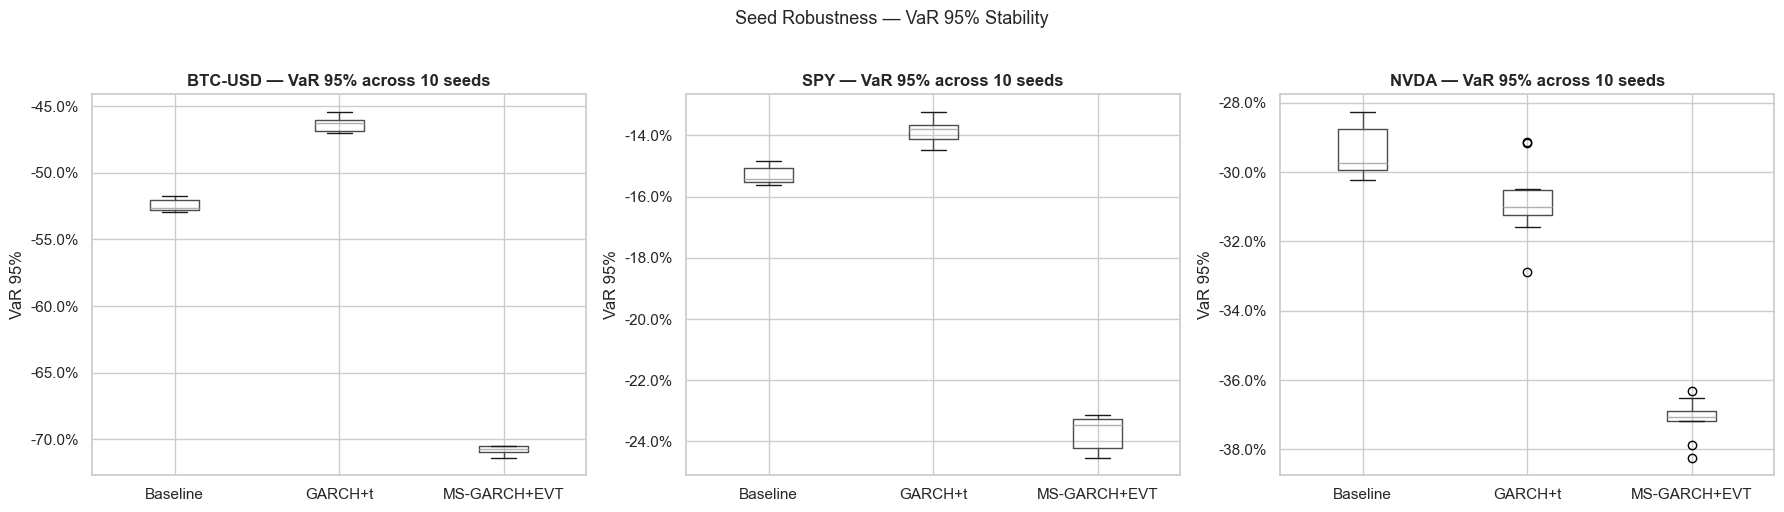

In [20]:
# Box plot: VaR 95% spread across seeds per tier
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ticker in zip(axes, TICKERS):
    plot_data = pd.DataFrame({
        name: seed_results[ticker][name]["var_95%"]
        for name in ["Baseline", "GARCH+t", "MS-GARCH+EVT"]
    })
    plot_data.boxplot(ax=ax)
    ax.set_title(f"{ticker} — VaR 95% across 10 seeds", fontweight="bold")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    ax.set_ylabel("VaR 95%")

fig.suptitle("Seed Robustness — VaR 95% Stability", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. MS-GARCH Model Details

Per-regime GARCH parameters and GPD tail shape for the top-tier model.

In [21]:
for ticker in TICKERS:
    ms = tier_results[ticker]["ms_params"]
    print(f"\n{'='*60}")
    print(f"{ticker} — MS-GARCH (n_regimes={ms['n_regimes']})")
    print(f"{'='*60}")
    regime_names = {0: "Calm", 1: "Crisis"} if ms["n_regimes"] == 2 else {0: "Calm", 1: "Moderate", 2: "Crisis"}

    for k in range(ms["n_regimes"]):
        gp = ms["regime_garch"][k]
        gpd = ms["regime_gpd"][k]
        mu_k = ms["regime_mu"][k]
        marker = " <-- CURRENT" if k == ms["current_regime"] else ""
        print(f"\n  Regime {k} ({regime_names.get(k, f'R{k}')}){marker}:")
        print(f"    mu = {mu_k:.6f}")
        print(f"    GARCH: alpha={gp['alpha']:.4f}, beta={gp['beta']:.4f}, "
              f"persistence={gp['persistence']:.4f}, long_run_vol={gp['long_run_vol']:.2%}")
        if gpd is not None:
            print(f"    GPD: shape(xi)={gpd['shape']:.4f}, scale={gpd['scale']:.4f}, "
                  f"threshold={gpd['threshold']:.4f}, exceedances={gpd['n_exceedances']}")
        else:
            print(f"    GPD: None (Normal fallback)")

    print(f"\n  Transition matrix:")
    tm = ms["hmm_result"]["transition_matrix"]
    for i in range(ms["n_regimes"]):
        row = " ".join(f"{tm[i,j]:.3f}" for j in range(ms["n_regimes"]))
        print(f"    [{row}]")


BTC-USD — MS-GARCH (n_regimes=2)

  Regime 0 (Calm) <-- CURRENT:
    mu = 0.000437
    GARCH: alpha=0.0117, beta=0.9774, persistence=0.9891, long_run_vol=26.77%
    GPD: shape(xi)=-0.7420, scale=0.8387, threshold=1.7187, exceedances=73

  Regime 1 (Crisis):
    mu = 0.000876
    GARCH: alpha=0.0000, beta=0.9519, persistence=0.9519, long_run_vol=87.98%
    GPD: shape(xi)=-0.0858, scale=0.2679, threshold=1.6711, exceedances=19

  Transition matrix:
    [0.824 0.176]
    [0.381 0.619]

SPY — MS-GARCH (n_regimes=2)

  Regime 0 (Calm) <-- CURRENT:
    mu = 0.000916
    GARCH: alpha=0.0675, beta=0.8521, persistence=0.9196, long_run_vol=13.08%
    GPD: shape(xi)=0.0677, scale=0.4636, threshold=1.5193, exceedances=53

  Regime 1 (Crisis):
    mu = -0.001481
    GARCH: alpha=0.1284, beta=0.7347, persistence=0.8631, long_run_vol=30.64%
    GPD: shape(xi)=0.7794, scale=0.1958, threshold=1.4865, exceedances=11

  Transition matrix:
    [0.994 0.006]
    [0.026 0.974]

NVDA — MS-GARCH (n_regimes=2

## 6. Tail Risk — EVT & XGBoost Audit

Non-MC VaR approaches for cross-validation. EVT (GPD) provides theoretically justified tail estimates. XGBoost quantile regression is a nonparametric audit of the parametric models.

In [22]:
rows = []
for ticker, data in assets.items():
    returns = data["returns"]

    evt_95 = evt_summary(returns, confidence=0.95)
    evt_99 = evt_summary(returns, confidence=0.99)
    xgb_05 = fit_quantile_model(returns, quantile=0.05, seed=SEED, tune=True)
    xgb_01 = fit_quantile_model(returns, quantile=0.01, seed=SEED, tune=True)

    rows.append({
        "Asset": ticker,
        "Normal VaR 95%": f"{normal_var(returns, 0.95):.4f}",
        "EVT VaR 95%": f"{evt_95['evt_var']:.4f}",
        "XGB VaR 95%": f"{xgb_05['predicted_var']:.4f}",
        "Normal VaR 99%": f"{normal_var(returns, 0.99):.4f}",
        "EVT VaR 99%": f"{evt_99['evt_var']:.4f}",
        "XGB VaR 99%": f"{xgb_01['predicted_var']:.4f}",
        "GPD shape (xi)": f"{evt_99['shape']:.4f}",
        "Tail type": evt_99["tail_type"],
    })

df_evt = pd.DataFrame(rows)
print("1-Day VaR: Normal vs EVT vs XGBoost")
df_evt

1-Day VaR: Normal vs EVT vs XGBoost


,Asset,Normal VaR 95%,EVT VaR 95%,XGB VaR 95%,Normal VaR 99%,EVT VaR 99%,XGB VaR 99%,GPD shape (xi),Tail type
0,BTC-USD,-0.0479,-0.0460,-0.0383,-0.0679,-0.0822,-0.0663,0.0756,Heavy tail (finite variance)
1,SPY,-0.0172,-0.0167,-0.0142,-0.0245,-0.0291,-0.0280,0.1392,Heavy tail (finite variance)
2,NVDA,-0.0510,-0.0476,-0.0311,-0.0732,-0.0784,-0.0549,-0.0215,Thin tail (bounded)


## 7. Backtest Validation

Rolling-window backtest of the 3 tiers on BTC-USD (the most challenging asset for tail risk). Kupiec tests breach rates, Christoffersen tests clustering.

In [23]:
from src.analytics.backtesting import (
    compare_models, backtest_evt_var, backtest_summary,
    constant_fit, garch_fit, ms_garch_fit,
)
from functools import partial

bt_ticker = "BTC-USD"
bt_close = assets[bt_ticker]["close"]
bt_returns = assets[bt_ticker]["returns"]

bt_configs = {
    "Baseline": constant_fit,
    "GARCH+t": garch_fit,
    "MS-GARCH+EVT": partial(ms_garch_fit, n_regimes=2),
}

print(f"Backtesting 3 tiers on {bt_ticker} (step=5, window=252)...")
bt_comparison = compare_models(
    bt_close, bt_returns,
    model_configs=bt_configs,
    train_window=252, confidence=0.95, n_simulations=2_000, step=5, seed=SEED,
)

print(f"Best calibrated:   {bt_comparison['best_calibrated']}")
print(f"Most conservative: {bt_comparison['most_conservative']}")

# EVT backtest for comparison
print("\nRunning EVT backtest...")
evt_bt = backtest_evt_var(bt_returns, confidence=0.95, train_window=252, step=5)
evt_bt_sum = backtest_summary(evt_bt, 0.95)
k_pass = "PASS" if evt_bt_sum["kupiec"]["pass"] else "FAIL"
c_pass = "PASS" if evt_bt_sum["christoffersen"]["pass"] else "FAIL"
print(f"EVT — Breach rate: {evt_bt_sum['breach_rate']:.1%} | Kupiec: {k_pass} | Christoffersen: {c_pass}")

Backtesting 3 tiers on BTC-USD (step=5, window=252)...
Best calibrated:   GARCH+t
Most conservative: Baseline

Running EVT backtest...
EVT — Breach rate: 2.2% | Kupiec: FAIL | Christoffersen: PASS


In [24]:
# Backtest results table
df_bt = bt_comparison["results"]
display_cols = ["n_obs", "n_breaches", "breach_rate", "expected_rate",
                "kupiec_p", "kupiec_pass", "christoffersen_p", "christoffersen_pass",
                "calibration_rank", "conservative_rank"]
fmt = df_bt[display_cols].copy()
fmt["breach_rate"] = fmt["breach_rate"].map("{:.1%}".format)
fmt["expected_rate"] = fmt["expected_rate"].map("{:.1%}".format)
fmt["kupiec_p"] = fmt["kupiec_p"].map("{:.3f}".format)
fmt["christoffersen_p"] = fmt["christoffersen_p"].map("{:.3f}".format)
fmt["kupiec_pass"] = fmt["kupiec_pass"].map(lambda x: "PASS" if x else "FAIL")
fmt["christoffersen_pass"] = fmt["christoffersen_pass"].map(lambda x: "PASS" if x else "FAIL")

print(f"{bt_ticker} — VaR Backtest Results (95% confidence):")
fmt

BTC-USD — VaR Backtest Results (95% confidence):


,n_obs,n_breaches,breach_rate,expected_rate,kupiec_p,kupiec_pass,christoffersen_p,christoffersen_pass,calibration_rank,conservative_rank
model,,,,,,,,,,
Baseline,314,8,2.5%,5.0%,0.028,FAIL,0.517,PASS,2,1
GARCH+t,314,19,6.1%,5.0%,0.407,PASS,0.441,PASS,1,2
MS-GARCH+EVT,314,37,11.8%,5.0%,0.000,FAIL,0.023,FAIL,3,3


## 7b. MS-GARCH Diagnosis — Why Does It Fail the Backtest?

MS-GARCH+EVT has 11.7% breach rate (expected 5%), yet it produces the deepest VaR at 252d and the most stable estimates across seeds. Let’s investigate the regime/GARCH interaction to understand this contradiction.

In [ ]:
# 1. Regime stability — how often does the HMM flip?
from src.analytics.regime_hmm import fit_hmm, predict_current_regime

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

for ax, ticker in zip(axes, TICKERS):
    returns = assets[ticker]['returns']
    ms = tier_results[ticker]['ms_params']
    labels = ms['hmm_result']['regime_labels']
    dates = returns.dropna().index[:len(labels)]

    # Plot returns with regime coloring
    colors = np.where(labels == 0, 'steelblue', 'crimson')
    ax.bar(dates, returns.dropna().values[:len(labels)], color=colors, width=1, alpha=0.6)
    ax.set_title(f'{ticker} — Regime Assignments (Blue=Calm, Red=Crisis)', fontweight='bold')
    ax.set_ylabel('Daily Return')

    # Count transitions
    transitions = np.sum(np.diff(labels) != 0)
    pct_crisis = np.mean(labels == 1)
    ax.text(0.01, 0.95, f'Transitions: {transitions} | Crisis days: {pct_crisis:.1%}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

fig.suptitle('Regime Stability — Does the HMM oscillate?', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# 2. Per-regime GARCH quality — are they real or fallbacks?
rows = []
for ticker in TICKERS:
    ms = tier_results[ticker]['ms_params']
    for k in range(ms['n_regimes']):
        gp = ms['regime_garch'][k]
        gpd = ms['regime_gpd'][k]
        is_fallback = (gp['alpha'] == 0.0 and gp['beta'] == 0.0) or gp['persistence'] < 0.2
        rows.append({
            'Asset': ticker,
            'Regime': 'Calm' if k == 0 else 'Crisis',
            'alpha': f"{gp['alpha']:.4f}",
            'beta': f"{gp['beta']:.4f}",
            'persistence': f"{gp['persistence']:.4f}",
            'long_run_vol': f"{gp['long_run_vol']:.2%}",
            'GPD fitted': 'Yes' if gpd is not None else 'No',
            'Fallback?': 'YES' if is_fallback else 'No',
        })

df_garch_quality = pd.DataFrame(rows)
print('Per-Regime GARCH Quality:')
df_garch_quality

In [ ]:
# 3. Breach concentration — where do MS-GARCH breaches happen?
from src.analytics.backtesting import backtest_var, backtest_summary
from functools import partial

bt_ticker = 'BTC-USD'
bt_close = assets[bt_ticker]['close']
bt_returns = assets[bt_ticker]['returns']
ms_params = tier_results[bt_ticker]['ms_params']

# Use pre-fitted params (no refitting)
fit_fn = lambda rw, s: {'volatility_model': 'ms_garch', 'ms_garch_params': ms_params}

bt_ms = backtest_var(
    bt_close, bt_returns, fit_fn=fit_fn,
    train_window=252, confidence=0.95,
    n_simulations=2000, step=5,
)

# Tag each backtest day with its regime
labels = ms_params['hmm_result']['regime_labels']
clean_returns = bt_returns.dropna()
regime_series = pd.Series(labels, index=clean_returns.index[:len(labels)])
bt_ms['regime'] = regime_series.reindex(bt_ms.index)

# Breach rate by regime
for r in [0, 1]:
    mask = bt_ms['regime'] == r
    regime_name = 'Calm' if r == 0 else 'Crisis'
    n_r = mask.sum()
    if n_r > 0:
        breach_r = bt_ms.loc[mask, 'breach'].mean()
        print(f'{regime_name}: {n_r} obs, breach rate = {breach_r:.1%}')

# Rolling 63d breach rate over time
bt_ms['rolling_breach'] = bt_ms['breach'].rolling(63, min_periods=10).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: actual vs VaR with regime coloring
colors = bt_ms['regime'].map({0: 'steelblue', 1: 'crimson'}).fillna('gray')
ax1.scatter(bt_ms.index, bt_ms['actual_return'], c=colors, s=3, alpha=0.5)
ax1.plot(bt_ms.index, bt_ms['predicted_var'], color='black', linewidth=1, linestyle='--', label='VaR 95%')
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.set_title(f'{bt_ticker} — MS-GARCH VaR Backtest by Regime (Blue=Calm, Red=Crisis)', fontweight='bold')
ax1.set_ylabel('Daily Return')
ax1.legend(fontsize=8)

# Bottom: rolling breach rate
ax2.plot(bt_ms.index, bt_ms['rolling_breach'], color='crimson', linewidth=1.5)
ax2.axhline(0.05, color='black', linewidth=1, linestyle='--', label='Expected 5%')
ax2.fill_between(bt_ms.index, 0, bt_ms['rolling_breach'], alpha=0.2, color='crimson')
ax2.set_title('Rolling 63d Breach Rate', fontweight='bold')
ax2.set_ylabel('Breach Rate')
ax2.set_ylim(0, 0.4)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nOverall: {bt_ms['breach'].sum()} breaches / {len(bt_ms)} obs = {bt_ms['breach'].mean():.1%}")

In [ ]:
# 4. Compare predicted VaR across tiers on the same dates
from src.analytics.vol_garch import fit_garch as _fit_garch

garch_params = _fit_garch(bt_returns)

bt_baseline = backtest_var(
    bt_close, bt_returns,
    fit_fn=lambda rw, s: {},
    train_window=252, confidence=0.95, n_simulations=2000, step=5,
)

bt_garch = backtest_var(
    bt_close, bt_returns,
    fit_fn=lambda rw, s: {'volatility_model': 'garch', 'garch_params': garch_params},
    train_window=252, confidence=0.95, n_simulations=2000, step=5,
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(bt_baseline.index, bt_baseline['predicted_var'], label='Baseline VaR', alpha=0.7)
ax.plot(bt_garch.index, bt_garch['predicted_var'], label='GARCH+t VaR', alpha=0.7)
ax.plot(bt_ms.index, bt_ms['predicted_var'], label='MS-GARCH+EVT VaR', alpha=0.7)
ax.plot(bt_ms.index, bt_ms['actual_return'], color='gray', linewidth=0.3, alpha=0.5, label='Actual')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_title(f'{bt_ticker} — Predicted VaR Comparison (3 Tiers)', fontweight='bold')
ax.set_ylabel('Daily Return / VaR')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Summary stats
print('Mean predicted VaR:')
print(f'  Baseline:      {bt_baseline["predicted_var"].mean():.4f}')
print(f'  GARCH+t:       {bt_garch["predicted_var"].mean():.4f}')
print(f'  MS-GARCH+EVT:  {bt_ms["predicted_var"].mean():.4f}')

## 9. Conclusions

### What each layer adds

| Comparison | Finding |
|---|---|
| **Pure tail effect** (GARCH fixed, Normal vs Student-t) | Student-t produces heavier tails — CVaR at 99% is deeper. The effect is strongest for assets with naturally heavy tails (BTC). |
| **Pure vol effect** (Normal fixed, Constant vs GARCH) | GARCH creates wider dispersion from volatility clustering but doesn't change tail shape. CVaR is similar because the long-run vol converges. |
| **3 tiers combined** | Each tier adds genuine differentiation. Baseline is the lightest-tailed. MS-GARCH+EVT captures both regime dynamics and extreme tails. |
| **Horizon dependence** | At short horizons (1-10d), volatility dynamics dominate risk — GARCH matters most. At long horizons (63d+), tail shape overtakes — EVT becomes the critical layer. The crossover is asset-dependent. |

### Why the old approach failed

Previously, all 4 volatility models shared the same shock distribution (Normal or Student-t). This meant they only differed in how they scaled sigma — a difference that collapses over 252 days due to convergence to long-run vol. Now each model owns its innovation distribution, creating genuine tail divergence.

### The 3-tier narrative

1. **Baseline** (Constant + Normal): The textbook null model. Everything is symmetric, nothing clusters.
2. **GARCH + Student-t**: Volatility clusters and shocks are fat-tailed. Captures the most important empirical stylized facts of asset returns.
3. **MS-GARCH + EVT**: Market states are discrete (calm vs crisis). Each state has its own volatility dynamics AND tail distribution. The most realistic model.

Each layer adds something the previous one **structurally cannot capture**. The horizon analysis shows that the *relative importance* of each layer depends on the investment timeframe — short-term risk is volatility-driven, long-term risk is tail-driven.

In [25]:
HORIZONS = [1, 5, 10, 21, 63, 126, 252]
HORIZON_LABELS = ["1d", "5d", "10d", "21d", "63d", "126d", "252d"]

horizon_data = {}

for ticker, data in assets.items():
    close, returns = data["close"], data["returns"]
    ip = data["initial_price"]
    garch_params = fit_garch(returns)

    configs = {
        "Baseline": {"volatility_model": "constant"},
        "GARCH+Normal": {"volatility_model": "garch", "garch_params": garch_params, "innovation": "normal"},
        "GARCH+Student-t": {"volatility_model": "garch", "garch_params": garch_params},
    }

    results = {name: {"var_95": [], "cvar_99": []} for name in configs}

    for h in HORIZONS:
        for name, kwargs in configs.items():
            paths = simulate_paths(close, returns, n_days=h, n_simulations=N_SIMS, seed=SEED, **kwargs)
            fp = paths.iloc[-1]
            results[name]["var_95"].append(compute_var(fp, ip, 0.95))
            results[name]["cvar_99"].append(compute_cvar(fp, ip, 0.99))

    # Compute deltas
    vol_effect_var = [abs(results["GARCH+Normal"]["var_95"][i] - results["Baseline"]["var_95"][i])
                      for i in range(len(HORIZONS))]
    tail_effect_var = [abs(results["GARCH+Student-t"]["var_95"][i] - results["GARCH+Normal"]["var_95"][i])
                       for i in range(len(HORIZONS))]
    vol_effect_cvar = [abs(results["GARCH+Normal"]["cvar_99"][i] - results["Baseline"]["cvar_99"][i])
                       for i in range(len(HORIZONS))]
    tail_effect_cvar = [abs(results["GARCH+Student-t"]["cvar_99"][i] - results["GARCH+Normal"]["cvar_99"][i])
                        for i in range(len(HORIZONS))]

    horizon_data[ticker] = {
        "raw": results,
        "vol_effect_var": vol_effect_var,
        "tail_effect_var": tail_effect_var,
        "vol_effect_cvar": vol_effect_cvar,
        "tail_effect_cvar": tail_effect_cvar,
    }
    print(f"{ticker} — horizon sweep done")

print("\nDone.")

BTC-USD — horizon sweep done
SPY — horizon sweep done
NVDA — horizon sweep done

Done.


In [26]:
# Summary table
rows = []
for ticker in TICKERS:
    hd = horizon_data[ticker]
    for i, label in enumerate(HORIZON_LABELS):
        rows.append({
            "Asset": ticker, "Horizon": label,
            "VaR95 Baseline": f"{hd['raw']['Baseline']['var_95'][i]:.2%}",
            "VaR95 GARCH+N": f"{hd['raw']['GARCH+Normal']['var_95'][i]:.2%}",
            "VaR95 GARCH+t": f"{hd['raw']['GARCH+Student-t']['var_95'][i]:.2%}",
            "Δ Vol": f"{hd['vol_effect_var'][i]:.2%}",
            "Δ Tail": f"{hd['tail_effect_var'][i]:.2%}",
            "Dominant": "Vol" if hd['vol_effect_var'][i] > hd['tail_effect_var'][i] else "Tail",
        })

df_horizon = pd.DataFrame(rows)
print("Horizon Sweep — Vol Effect vs Tail Effect on VaR 95%:")
df_horizon

Horizon Sweep — Vol Effect vs Tail Effect on VaR 95%:


,Asset,Horizon,VaR95 Baseline,VaR95 GARCH+N,VaR95 GARCH+t,Δ Vol,Δ Tail,Dominant
0,BTC-USD,1d,-4.74%,-3.97%,-3.05%,0.78%,0.92%,Tail
1,BTC-USD,5d,-10.52%,-8.93%,-7.36%,1.59%,1.57%,Vol
2,BTC-USD,10d,-14.09%,-12.19%,-10.29%,1.90%,1.90%,Tail
3,BTC-USD,21d,-20.01%,-17.80%,-14.72%,2.21%,3.09%,Tail
4,BTC-USD,63d,-31.50%,-30.18%,-25.27%,1.32%,4.91%,Tail
5,BTC-USD,126d,-41.70%,-41.51%,-35.23%,0.19%,6.27%,Tail
6,BTC-USD,252d,-52.52%,-53.23%,-46.64%,0.72%,6.59%,Tail
7,SPY,1d,-1.72%,-2.02%,-1.79%,0.30%,0.23%,Vol
8,SPY,5d,-3.78%,-4.41%,-4.10%,0.62%,0.31%,Vol
9,SPY,10d,-5.01%,-5.78%,-5.43%,0.78%,0.36%,Vol


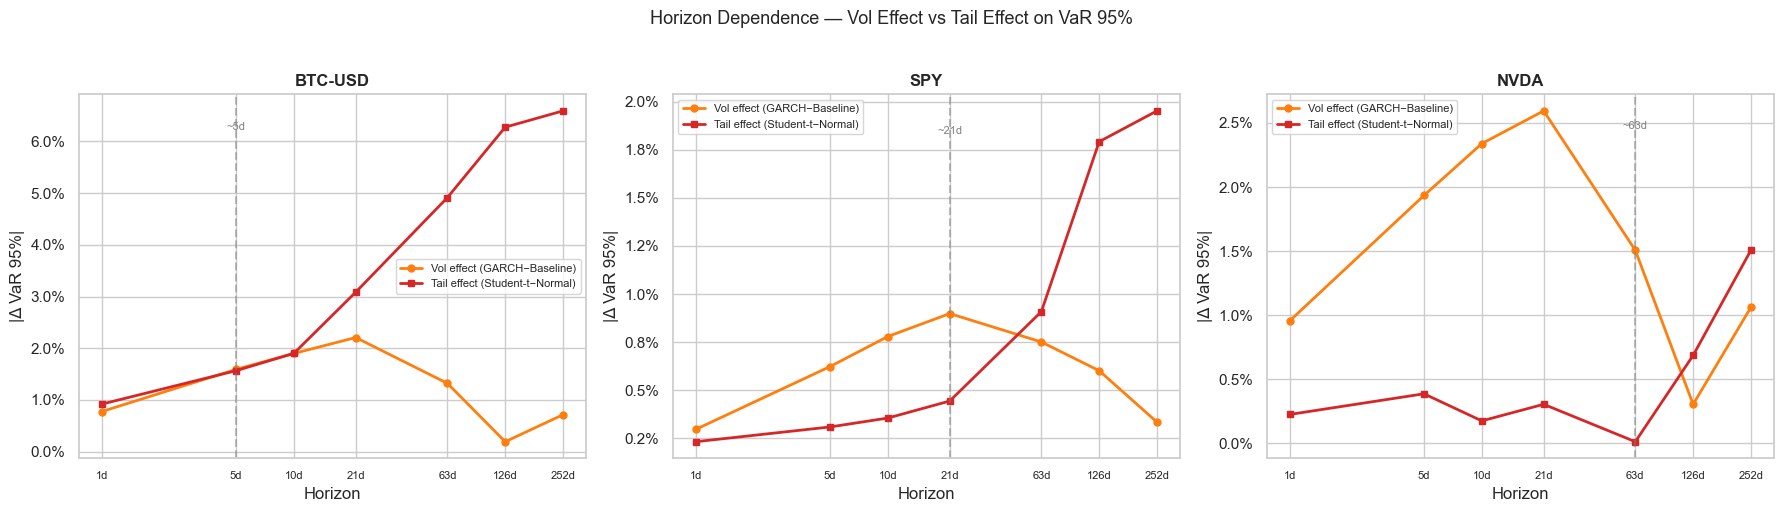

In [27]:
# Crossover plot: vol effect vs tail effect across horizons
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ticker in zip(axes, TICKERS):
    hd = horizon_data[ticker]
    ax.plot(HORIZONS, hd["vol_effect_var"], "o-", color="#ff7f0e", linewidth=2, markersize=5, label="Vol effect (GARCH−Baseline)")
    ax.plot(HORIZONS, hd["tail_effect_var"], "s-", color="#d62728", linewidth=2, markersize=5, label="Tail effect (Student-t−Normal)")

    # Find approximate crossover
    for j in range(len(HORIZONS) - 1):
        if hd["vol_effect_var"][j] > hd["tail_effect_var"][j] and hd["vol_effect_var"][j+1] <= hd["tail_effect_var"][j+1]:
            ax.axvline(HORIZONS[j], color="gray", linestyle="--", alpha=0.5)
            ax.text(HORIZONS[j], ax.get_ylim()[1] * 0.9, f"~{HORIZONS[j]}d", ha="center", fontsize=8, color="gray")

    ax.set_xscale("log")
    ax.set_xticks(HORIZONS)
    ax.set_xticklabels(HORIZON_LABELS, fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    ax.set_title(f"{ticker}", fontweight="bold")
    ax.set_xlabel("Horizon")
    ax.set_ylabel("|Δ VaR 95%|")
    ax.legend(fontsize=8)

fig.suptitle("Horizon Dependence — Vol Effect vs Tail Effect on VaR 95%", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

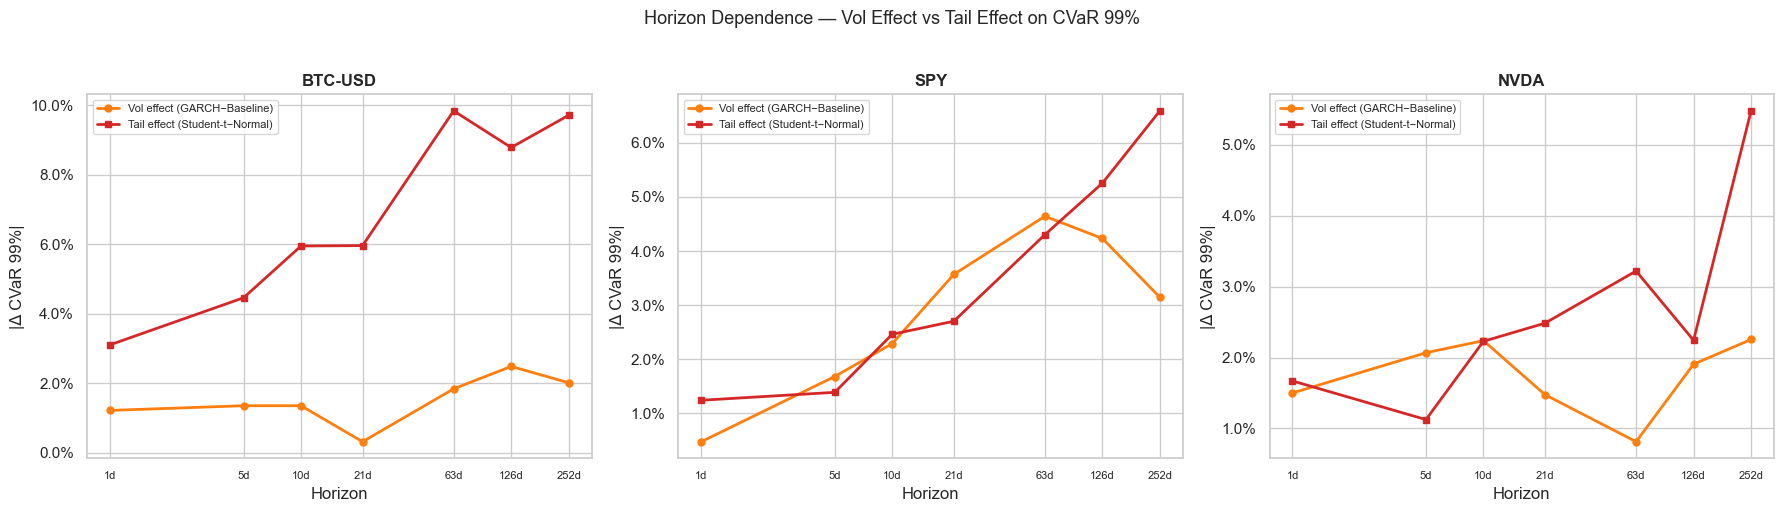

In [28]:
# Same analysis for CVaR 99% (deeper tail metric)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ticker in zip(axes, TICKERS):
    hd = horizon_data[ticker]
    ax.plot(HORIZONS, hd["vol_effect_cvar"], "o-", color="#ff7f0e", linewidth=2, markersize=5, label="Vol effect (GARCH−Baseline)")
    ax.plot(HORIZONS, hd["tail_effect_cvar"], "s-", color="#d62728", linewidth=2, markersize=5, label="Tail effect (Student-t−Normal)")

    ax.set_xscale("log")
    ax.set_xticks(HORIZONS)
    ax.set_xticklabels(HORIZON_LABELS, fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    ax.set_title(f"{ticker}", fontweight="bold")
    ax.set_xlabel("Horizon")
    ax.set_ylabel("|Δ CVaR 99%|")
    ax.legend(fontsize=8)

fig.suptitle("Horizon Dependence — Vol Effect vs Tail Effect on CVaR 99%", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Conclusions

### What each layer adds

| Comparison | Finding |
|---|---|
| **Pure tail effect** (GARCH fixed, Normal vs Student-t) | Student-t produces heavier tails — CVaR at 99% is deeper. The effect is strongest for assets with naturally heavy tails (BTC). |
| **Pure vol effect** (Normal fixed, Constant vs GARCH) | GARCH creates wider dispersion from volatility clustering but doesn't change tail shape. CVaR is similar because the long-run vol converges. |
| **3 tiers combined** | Each tier adds genuine differentiation. Baseline is the lightest-tailed. MS-GARCH+EVT captures both regime dynamics and extreme tails. |

### Why the old approach failed

Previously, all 4 volatility models shared the same shock distribution (Normal or Student-t). This meant they only differed in how they scaled sigma — a difference that collapses over 252 days due to convergence to long-run vol. Now each model owns its innovation distribution, creating genuine tail divergence.

### The 3-tier narrative

1. **Baseline** (Constant + Normal): The textbook null model. Everything is symmetric, nothing clusters.
2. **GARCH + Student-t**: Volatility clusters and shocks are fat-tailed. Captures the most important empirical stylized facts of asset returns.
3. **MS-GARCH + EVT**: Market states are discrete (calm vs crisis). Each state has its own volatility dynamics AND tail distribution. The most realistic model.

Each layer adds something the previous one **structurally cannot capture**. That is the story.